In [1]:
import os
import json
import pandas as pd
from collections import Counter, defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
turns_df = pd.read_parquet("turns_dataset.parquet")
ends_df = pd.read_parquet("game_results.parquet")

In [3]:
with open("cards.json", "r", encoding="utf-8") as f:
    cards_data = json.load(f)

cards_df = pd.DataFrame(cards_data)
card_features_df = pd.read_csv("card_features.csv")

In [4]:
card_id_to_name = dict(zip(cards_df["id"], cards_df["Name"]))
card_id_to_deck = dict(zip(cards_df["id"], cards_df["Deck"]))

In [5]:
deck_id_to_name = {
    0: "Ansei", 1: "Duke of Crows", 2: "Rajhin", 4: "Orgnum",
    5: "Hlaalu", 6: "Pelin", 7: "Red Eagle", 8: "Treasury", 9: "Saint Alessia"
}

In [ ]:
card_counter = Counter()
for _, row in turns_df.iterrows():
    if row.get("Type") != "turn":
        continue

    chosen = row.get("Chosen")
    legal_moves = row.get("LegalMoves")

    if not (isinstance(legal_moves, np.ndarray) and isinstance(chosen, int) and 0 <= chosen < len(legal_moves)):
        continue

    move = legal_moves[chosen]
    cmd = move.get("Cmd")
    card_id = move.get("Arg")

    if card_id is None:
        continue
    card_id = int(card_id)
    if cmd in [0, 1]:
        card_counter[card_id] += 1

    elif cmd == 3:
        card_row = cards_df[cards_df["id"] == card_id]
        if not card_row.empty and card_row["Type"].values[0] == "Contract Action":
            card_counter[card_id] += 1

card_stats = pd.DataFrame(card_counter.items(), columns=['card_id', 'times_played'])
card_stats = card_stats.merge(cards_df[['id', 'Name', 'Deck', 'Cost']],
                                left_on='card_id', right_on='id', how='left')
card_stats = card_stats[
    (card_stats['Deck'] != 'Treasury') &
    (card_stats['Cost'] > 0)
]
card_stats = card_stats.sort_values(by='times_played', ascending=False)
card_stats = card_stats.rename(columns={"Name": "card_name"})
card_stats = card_stats[['card_id', 'card_name', 'Deck', 'Cost', 'times_played']]

In [7]:
deck_entries = []
for _, row in ends_df.iterrows():
    for player in row['players']:
        for deck in player['DecksPicked']:
            deck_entries.append({
                'game_id': row['game_id'],
                'side': player['Side'],
                'deck': deck,
                'winner': (player['Side'] == row['winner'])
            })

deck_df = pd.DataFrame(deck_entries)
deck_stats = deck_df.groupby('deck').agg(
    games=('game_id', 'count'),
    wins=('winner', 'sum')
).reset_index()
deck_stats['win_rate'] = deck_stats['wins'] / deck_stats['games']
deck_stats['deck_name'] = deck_stats['deck'].map(deck_id_to_name)

In [8]:
turn_counts = turns_df.groupby('GameId')['TurnIdx'].max().reset_index(name='max_turn')

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


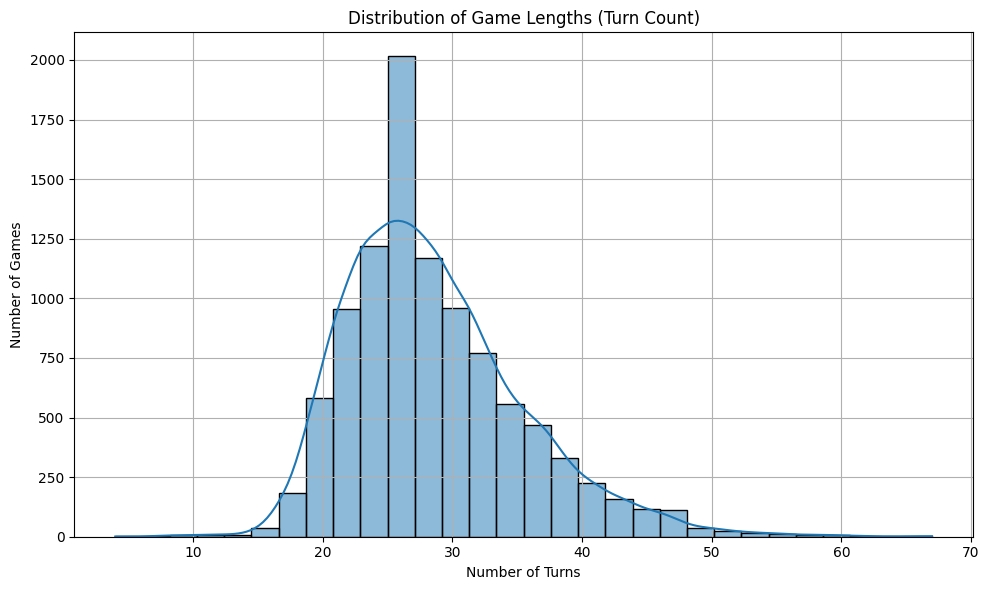

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(turn_counts['max_turn'], bins=30, kde=True)
plt.title("Distribution of Game Lengths (Turn Count)")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Games")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
print("\n=== Najczęściej zagrywane karty ===")
print(card_stats[['card_id', 'card_name', 'Deck', 'times_played']].head(10))

print("\n=== Statystyki decków ===")
print(deck_stats[['deck', 'deck_name', 'games', 'wins', 'win_rate']])


=== Najczęściej zagrywane karty ===
    card_id              card_name           Deck  times_played
21       13          Midnight Raid      Red Eagle         15512
74       86         Slight of Hand         Rajhin         14552
51        1         Luxury Exports         Hlaalu         13953
25       45           Warrior Wave          Ansei         13547
23       39               Conquest          Ansei         12915
15      122          Saint's Wrath  Saint Alessia         10524
42      102      Summerset Sacking         Orgnum          9965
82      116   Chainbreaker Captain  Saint Alessia          9854
34       28          Toll of Flesh          Crows          9535
62      118  Morihaus, Sacred Bull  Saint Alessia          9284

=== Statystyki decków ===
   deck      deck_name  games  wins  win_rate
0     0          Ansei   5081  2541  0.500098
1     1  Duke of Crows   5038  2530  0.502183
2     2         Rajhin   4992  2466  0.493990
3     4         Orgnum   4992  2478  0.496394
4 

In [11]:
pair_entries = []

for _, row in ends_df.iterrows():
    for player in row["players"]:
        decks = tuple(sorted(player["DecksPicked"]))
        pair_entries.append({
            "game_id": row["game_id"],
            "pair": decks,
            "winner": (player["Side"] == row["winner"])
        })

pair_df = pd.DataFrame(pair_entries)

pair_stats = pair_df.groupby("pair").agg(
    games=("game_id", "count"),
    wins=("winner", "sum")
).reset_index()

pair_stats["win_rate"] = pair_stats["wins"] / pair_stats["games"]

def pair_to_names(pair):
    return tuple(deck_id_to_name[deck_id] for deck_id in pair)

pair_stats["pair_names"] = pair_stats["pair"].apply(pair_to_names)

pair_stats[["deck_1", "deck_2"]] = pd.DataFrame(pair_stats["pair_names"].tolist(), index=pair_stats.index)

pair_stats = pair_stats.sort_values(by="games", ascending=False)
filtered = pair_stats[pair_stats["games"] >= 100]

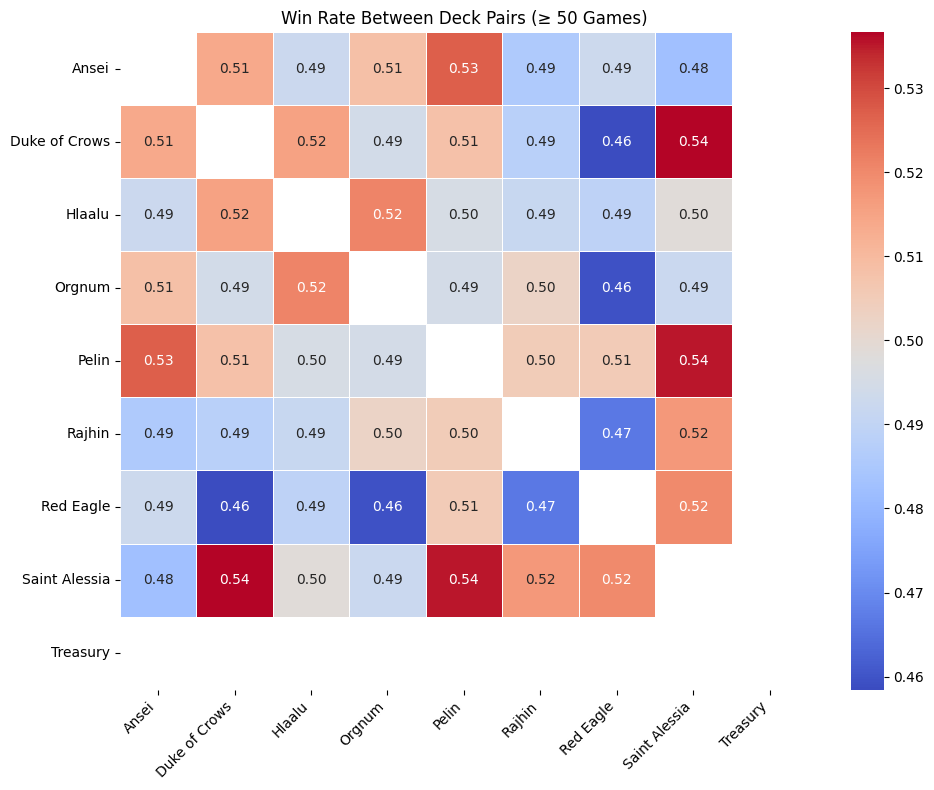

In [12]:
heatmap_data = pair_stats.copy()
heatmap_data["pair_key"] = heatmap_data.apply(lambda row: tuple(sorted((row["deck_1"], row["deck_2"]))), axis=1)
heatmap_data = heatmap_data.groupby("pair_key").agg({"win_rate": "mean"}).reset_index()
heatmap_data[["deck_1", "deck_2"]] = pd.DataFrame(heatmap_data["pair_key"].tolist(), index=heatmap_data.index)

deck_names = list(deck_id_to_name.values())
deck_names.sort()

heatmap_matrix = pd.DataFrame(
    np.nan, index=deck_names, columns=deck_names
)

for _, row in heatmap_data.iterrows():
    d1 = row["deck_1"]
    d2 = row["deck_2"]
    wr = row["win_rate"]
    heatmap_matrix.loc[d1, d2] = wr
    heatmap_matrix.loc[d2, d1] = wr

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Win Rate Between Deck Pairs (≥ 50 Games)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
player_deck_usage = defaultdict(Counter)

for _, row in turns_df.iterrows():
    if row.get("Type") != "turn":
        continue

    game_id = row["GameId"]
    side = row["ActivePlayer"]
    chosen = row.get("Chosen")
    legal_moves = row.get("LegalMoves")

    if not (isinstance(legal_moves, np.ndarray) and isinstance(chosen, int) and 0 <= chosen < len(legal_moves)):
        continue

    move = legal_moves[chosen]
    cmd = move.get("Cmd")
    card_id = move.get("Arg")

    if card_id is None:
        continue
    card_id = int(card_id)
    if cmd in [0, 1]:
        deck = card_id_to_deck.get(card_id)
        if deck and deck != "Treasury":
            player_deck_usage[(game_id, side)][deck] += 1

    elif cmd == 3:
        card_row = cards_df[cards_df["id"] == card_id]
        if not card_row.empty and card_row["Type"].values[0] == "Contract Action":
            deck = card_id_to_deck.get(card_id)
            if deck and deck != "Treasury":
                player_deck_usage[(game_id, side)][deck] += 1

In [59]:
dominant_decks = []
for (game_id, side), deck_counter in player_deck_usage.items():
    total = sum(deck_counter.values())
    if total == 0:
        continue
    top_deck, count = deck_counter.most_common(1)[0]
    if count / total >= 0.5:
        dominant_decks.append({
            "game_id": game_id,
            "side": side,
            "dominant_deck": top_deck
        })

In [60]:
dominant_df = pd.DataFrame(dominant_decks)
win_info = []
for _, row in ends_df.iterrows():
    for player in row["players"]:
        win_info.append({
            "game_id": row["game_id"],
            "side": player["Side"],
            "is_winner": (player["Side"] == row["winner"])
        })

wins_df = pd.DataFrame(win_info)
result_df = pd.merge(dominant_df, wins_df, on=["game_id", "side"])

In [61]:
deck_win_stats = result_df.groupby("dominant_deck").agg(
    games=("game_id", "count"),
    wins=("is_winner", "sum")
).reset_index()

deck_win_stats["win_rate"] = deck_win_stats["wins"] / deck_win_stats["games"]
deck_win_stats = deck_win_stats.sort_values(by="win_rate", ascending=False)

In [17]:
deck_win_stats.head(10)

,dominant_deck,games,wins,win_rate
4,Pelin,700,489,0.698571
6,Red Eagle,324,225,0.694444
0,Ansei,815,536,0.657669
1,Crows,1421,827,0.581985
3,Orgnum,180,104,0.577778
2,Hlaalu,222,119,0.536036
7,Saint Alessia,839,429,0.511323
5,Rajhin,1451,617,0.425224


In [18]:
deck_distribution_df = pd.DataFrame([
    {
        "game_id": game_id,
        "side": side,
        **{f"deck_{deck}": count for deck, count in usage.items()}
    }
    for (game_id, side), usage in player_deck_usage.items()
])
deck_distribution_df.head(10)

,game_id,side,deck_Hlaalu,deck_Ansei,deck_Pelin,deck_Saint Alessia,deck_Red Eagle,deck_Crows,deck_Orgnum,deck_Rajhin
0,0000e7b4-ef9b-4bf7-a196-8368c274295f,0,5.0,10.0,10.0,10.0,NaN,NaN,NaN,NaN
1,0000e7b4-ef9b-4bf7-a196-8368c274295f,1,7.0,8.0,10.0,7.0,NaN,NaN,NaN,NaN
2,000b3eb9-a0d6-4da1-9429-5f4ac2111a4d,0,7.0,10.0,NaN,4.0,6.0,NaN,NaN,NaN
3,000b3eb9-a0d6-4da1-9429-5f4ac2111a4d,1,5.0,6.0,NaN,5.0,12.0,NaN,NaN,NaN
4,000fdff3-0f97-413b-aaec-d79317a3927e,0,NaN,NaN,NaN,9.0,6.0,23.0,7.0,NaN
5,000fdff3-0f97-413b-aaec-d79317a3927e,1,NaN,NaN,NaN,8.0,4.0,20.0,16.0,NaN
6,0010ab74-6072-4f39-bdbb-201cc5f9d4c6,0,3.0,NaN,9.0,NaN,10.0,5.0,NaN,NaN
7,0010ab74-6072-4f39-bdbb-201cc5f9d4c6,1,2.0,NaN,10.0,NaN,6.0,4.0,NaN,NaN
8,001d2c14-93a2-4c75-963f-4ae72a00ab67,0,7.0,15.0,7.0,NaN,NaN,NaN,NaN,6.0
9,001d2c14-93a2-4c75-963f-4ae72a00ab67,1,10.0,6.0,9.0,NaN,NaN,NaN,NaN,11.0


In [19]:

full_df = pd.merge(deck_distribution_df, wins_df, on=["game_id", "side"])
full_df.to_parquet("deck_usage_with_win.parquet", index=False)
result_df.to_parquet("dominant_decks_and_win.parquet", index=False)

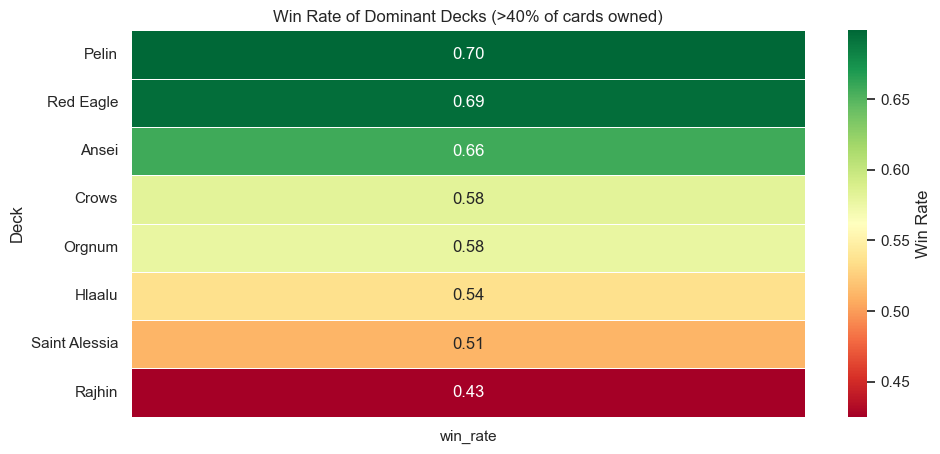

In [53]:
deck_win_stats = deck_win_stats.set_index("dominant_deck")

plt.figure(figsize=(10, 1.5 + 0.4 * len(deck_win_stats)))
sns.heatmap(
    deck_win_stats[["win_rate"]],
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Win Rate"}
)

plt.title("Win Rate of Dominant Decks (>40% of cards owned)")
plt.ylabel("Deck")
plt.xlabel("")
plt.tight_layout()
plt.show()

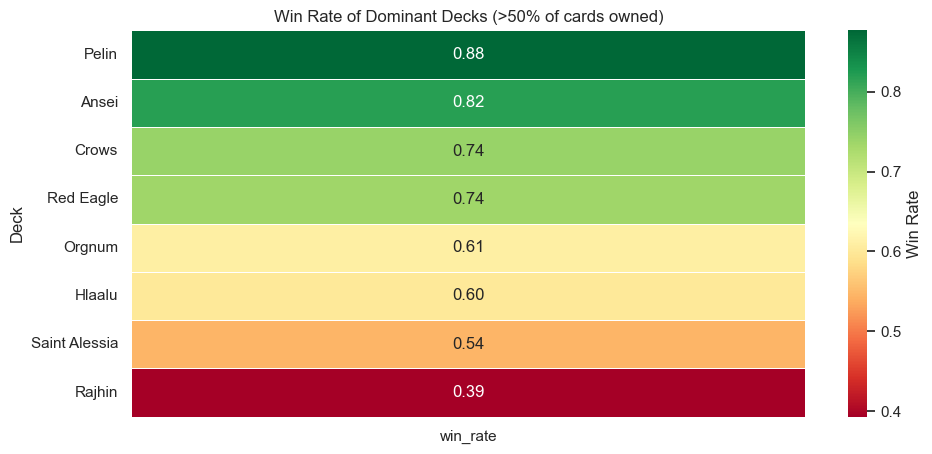

In [62]:
deck_win_stats = deck_win_stats.set_index("dominant_deck")

plt.figure(figsize=(10, 1.5 + 0.4 * len(deck_win_stats)))
sns.heatmap(
    deck_win_stats[["win_rate"]],
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Win Rate"}
)

plt.title("Win Rate of Dominant Decks (>50% of cards owned)")
plt.ylabel("Deck")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
deck_usage_per_game = defaultdict(Counter)

for _, row in turns_df.iterrows():
    if row.get("Type") != "turn":
        continue

    game_id = row["GameId"]
    chosen = row.get("Chosen")
    legal_moves = row.get("LegalMoves")

    if not (isinstance(legal_moves, np.ndarray) and isinstance(chosen, int) and 0 <= chosen < len(legal_moves)):
        continue

    move = legal_moves[chosen]
    cmd = move.get("Cmd")
    card_id = move.get("Arg")

    if card_id is None:
        continue
    card_id = int(card_id)

    if cmd in [0, 1]:
        deck = card_id_to_deck.get(card_id)
        if deck:
            deck_usage_per_game[game_id][deck] += 1

    elif cmd == 3:
        card_row = cards_df[cards_df["id"] == card_id]
        if not card_row.empty and card_row["Type"].values[0] == "Contract Action":
            deck = card_id_to_deck.get(card_id)
            if deck:
                deck_usage_per_game[game_id][deck] += 1

total_usage = Counter()
games_with_deck = Counter()

for game_id, usage in deck_usage_per_game.items():
    for deck, count in usage.items():
        total_usage[deck] += count
        games_with_deck[deck] += 1

deck_popularity_df = pd.DataFrame([
    {
        "deck": deck,
        "total_plays": total_usage[deck],
        "games_with_deck": games_with_deck[deck],
        "avg_plays_per_game": total_usage[deck] / games_with_deck[deck]
    }
    for deck in total_usage
]).sort_values(by="total_plays", ascending=False)

deck_popularity_df = deck_popularity_df[["deck", "total_plays", "games_with_deck", "avg_plays_per_game"]]

In [22]:
deck_popularity_df.head(10)

,deck,total_plays,games_with_deck,avg_plays_per_game
0,Treasury,819515,10000,81.951500
8,Rajhin,148028,4992,29.653045
6,Crows,130021,5038,25.808059
4,Saint Alessia,117820,5002,23.554578
2,Ansei,107801,5081,21.216493
3,Pelin,95776,5003,19.143714
5,Red Eagle,89239,4922,18.130638
1,Hlaalu,87646,4970,17.635010
7,Orgnum,80520,4992,16.129808


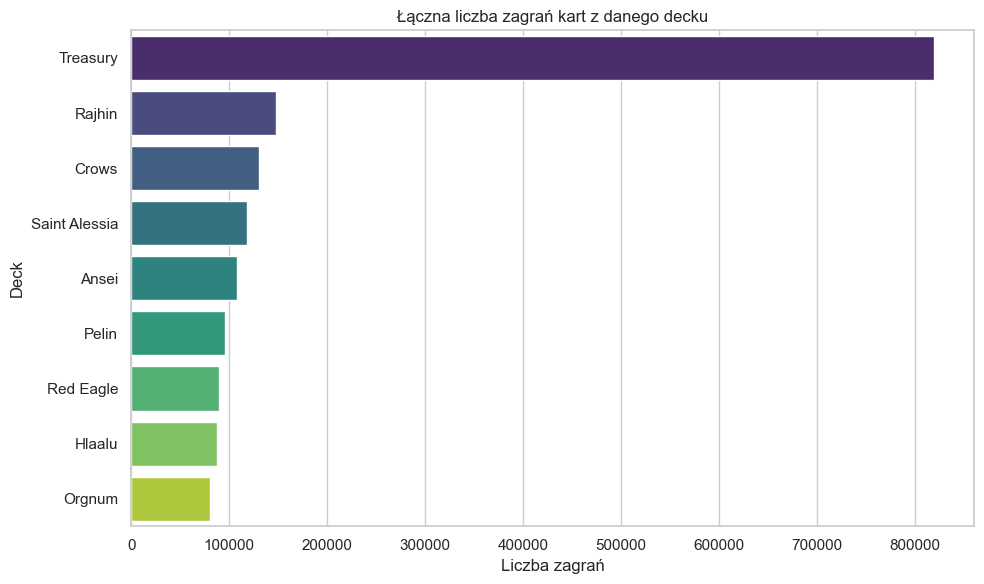

In [23]:
deck_popularity_df = deck_popularity_df.sort_values(by="total_plays", ascending=False)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=deck_popularity_df,
    x="total_plays",
    y="deck",
    palette="viridis"
)
plt.title("Łączna liczba zagrań kart z danego decku")
plt.xlabel("Liczba zagrań")
plt.ylabel("Deck")
plt.tight_layout()
plt.show()

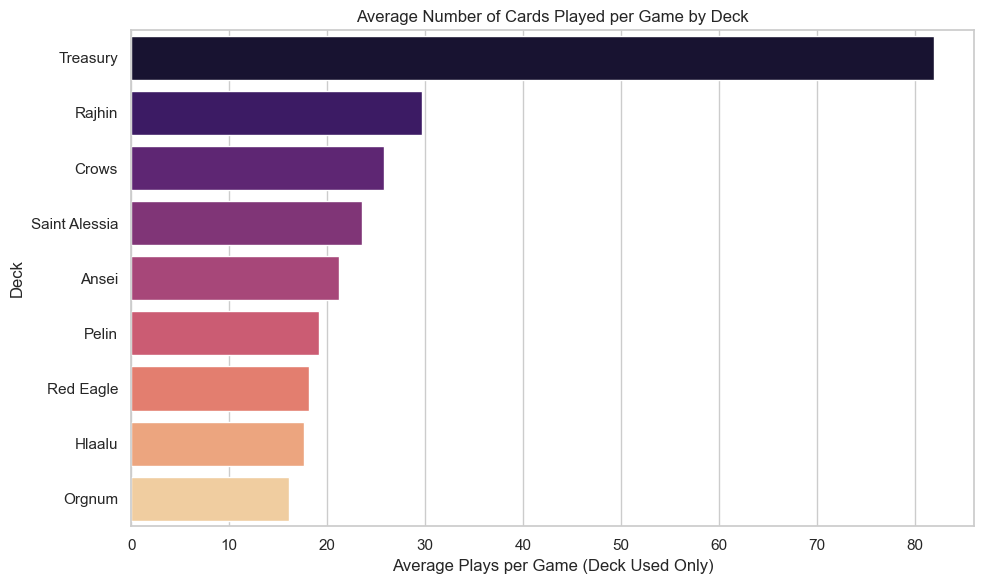

In [24]:
plt.figure(figsize=(10, 6))
deck_popularity_df = deck_popularity_df.sort_values(by="avg_plays_per_game", ascending=False)
sns.barplot(
    data=deck_popularity_df,
    x="avg_plays_per_game",
    y="deck",
    palette="magma"
)
plt.title("Average Number of Cards Played per Game by Deck")
plt.xlabel("Average Plays per Game (Deck Used Only)")
plt.ylabel("Deck")
plt.tight_layout()
plt.show()

In [25]:
card_game_stats = []

winner_lookup = {
    (row["game_id"], player["Side"]): (player["Side"] == row["winner"])
    for _, row in ends_df.iterrows()
    for player in row["players"]
}
per_game_player_card_plays = defaultdict(lambda: Counter())

In [ ]:
for _, row in turns_df.iterrows():
    if row.get("Type") != "turn":
        continue

    game_id = row["GameId"]
    side = row["ActivePlayer"]
    chosen = row.get("Chosen")
    legal_moves = row.get("LegalMoves")

    if not (isinstance(legal_moves, np.ndarray) and isinstance(chosen, int) and 0 <= chosen < len(legal_moves)):
        continue

    move = legal_moves[chosen]
    cmd = move.get("Cmd")
    card_id = move.get("Arg")

    if card_id is None:
        continue
    card_id = int(card_id)

    card_row = cards_df[cards_df["id"] == card_id]
    if card_row.empty:
        continue

    cost = card_row["Cost"].values[0]
    if cost == 0:
        continue

    if cmd in [0, 1]:  # PLAY_CARD or ACTIVATE_AGENT
        per_game_player_card_plays[(game_id, side)][card_id] += 1
    elif cmd == 3:
        if not card_row.empty and card_row["Type"].values[0] == "Contract Action":
            per_game_player_card_plays[(game_id, side)][card_id] += 1


In [27]:
card_game_stats = []
for (game_id, side), card_counts in per_game_player_card_plays.items():
    total_plays = sum(card_counts.values())
    if total_plays == 0:
        continue

    win = winner_lookup.get((game_id, side), False)

    for card_id, count in card_counts.items():
        play_ratio = count / total_plays
        card_row = cards_df[cards_df["id"] == card_id]
        if not card_row.empty:
            cost = card_row["Cost"].values[0]
            type_ = card_row["Type"].values[0]
        else:
            cost = np.nan
            type_ = "Unknown"
        card_game_stats.append({
            "game_id": game_id,
            "side": side,
            "card_id": card_id,
            "card_name": card_id_to_name.get(card_id, f"Card {card_id}"),
            "plays": count,
            "play_ratio": play_ratio,
            "win": win,
            "cost": cost,
            "type": type_,
        })


In [28]:
df = pd.DataFrame(card_game_stats)

agg = df.groupby("card_id").agg(
    total_plays=("plays", "sum"),
    play_ratio_sum=("play_ratio", "sum"),
    weighted_win_score=("play_ratio", lambda x: x.dot(df.loc[x.index, 'win']))
).reset_index()

agg["weighted_win_rate"] = agg["weighted_win_score"] / agg["play_ratio_sum"]
agg["card_name"] = agg["card_id"].map(card_id_to_name)
agg = agg.sort_values(by="weighted_win_rate", ascending=False)

In [29]:
df["loss"] = ~df["win"]

loss_agg = df.groupby("card_id").agg(
    total_plays=("plays", "sum"),
    play_ratio_sum=("play_ratio", "sum"),
    weighted_loss_score=("play_ratio", lambda x: x.dot(df.loc[x.index, 'loss']))
).reset_index()

loss_agg["weighted_loss_rate"] = loss_agg["weighted_loss_score"] / loss_agg["play_ratio_sum"]
loss_agg["card_name"] = loss_agg["card_id"].map(card_id_to_name)

loss_agg = loss_agg.sort_values(by="weighted_loss_rate", ascending=False)

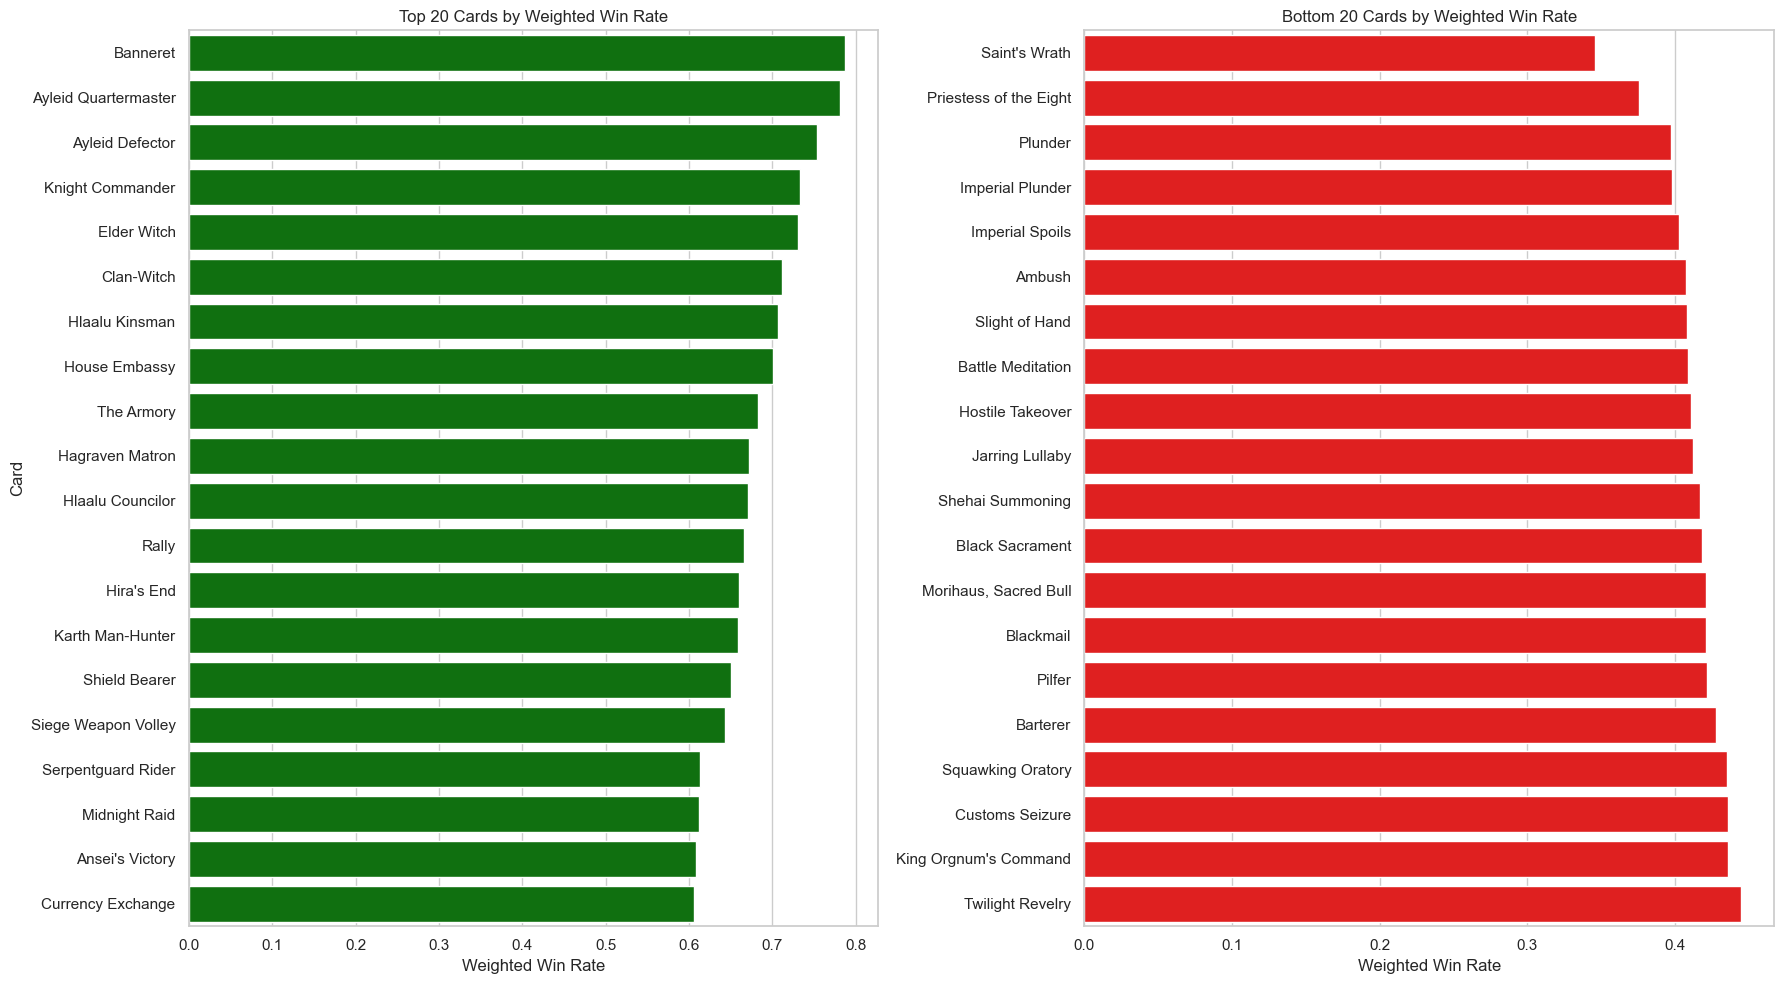

In [30]:
top_cards = agg.sort_values(by="weighted_win_rate", ascending=False).head(20).copy()
flop_cards = agg.sort_values(by="weighted_win_rate", ascending=True).head(20).copy()

top_cards["group"] = "Top"
flop_cards["group"] = "Flop"

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=False)

sns.barplot(
    data=top_cards,
    x="weighted_win_rate",
    y="card_name",
    color="green",
    ax=axes[0]
)
axes[0].set_title("Top 20 Cards by Weighted Win Rate")
axes[0].set_xlabel("Weighted Win Rate")
axes[0].set_ylabel("Card")

sns.barplot(
    data=flop_cards,
    x="weighted_win_rate",
    y="card_name",
    color="red",
    ax=axes[1]
)
axes[1].set_title("Bottom 20 Cards by Weighted Win Rate")
axes[1].set_xlabel("Weighted Win Rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

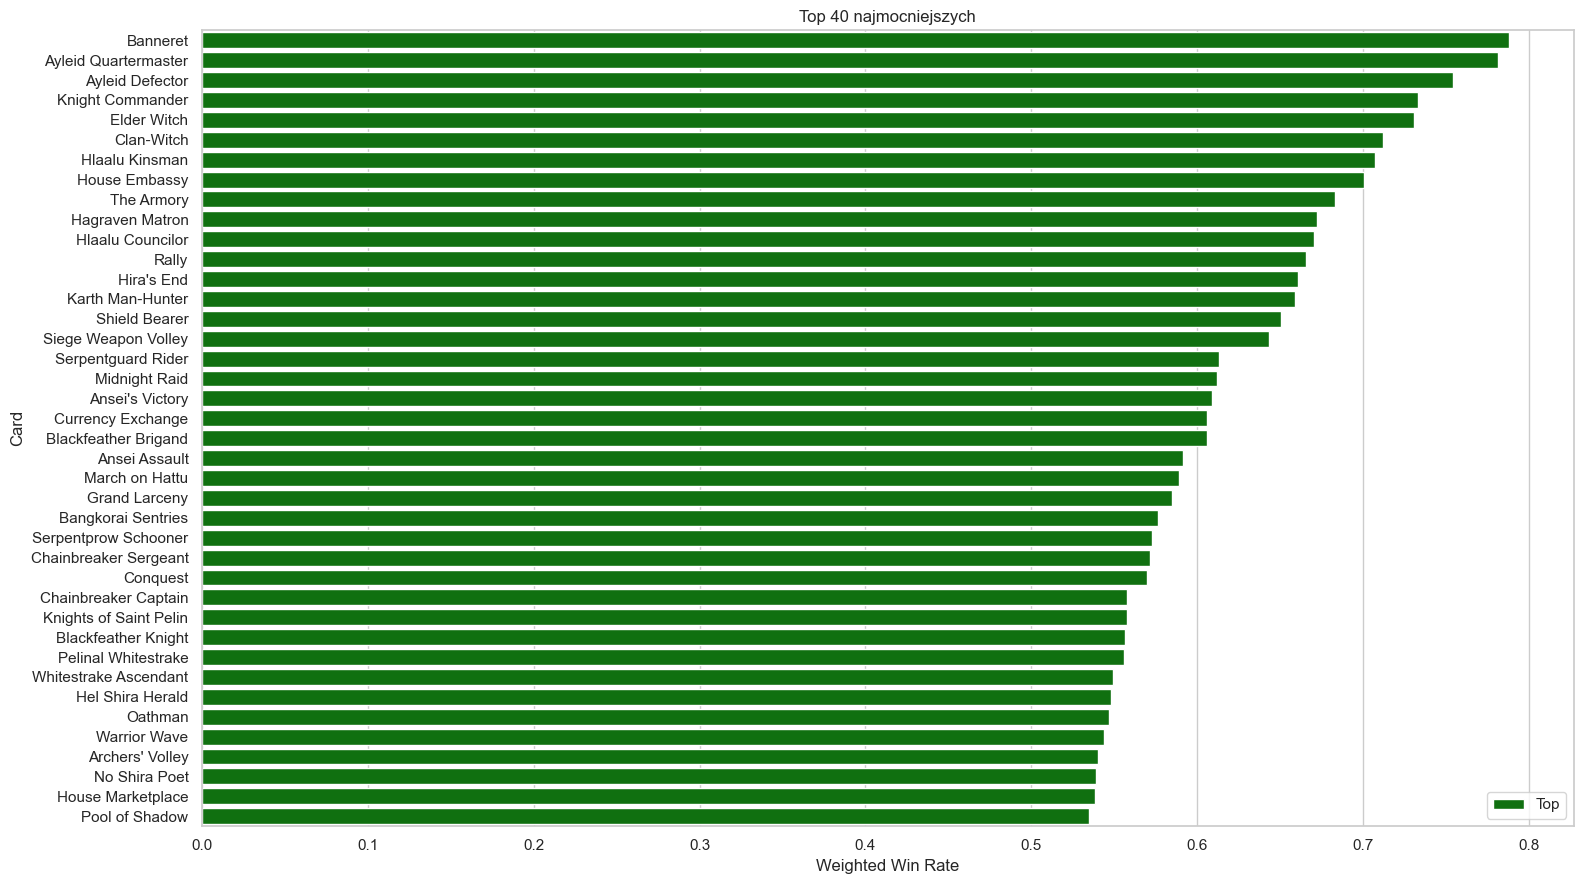

In [31]:
top_cards = agg.sort_values(by="weighted_win_rate", ascending=False).head(40).copy()
top_cards["group"] = "Top"
plt.figure(figsize=(16, 9))
sns.barplot(
    data=top_cards,
    x="weighted_win_rate",
    y="card_name",
    hue="group",
    dodge=False,
    palette={"Top": "green", "Flop": "red"}
)
plt.xlabel("Weighted Win Rate")
plt.ylabel("Card")
plt.title("Top 40 najmocniejszych")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [32]:
result = agg[["card_id", "weighted_win_rate"]].sort_values(by="weighted_win_rate", ascending=False)

result.to_csv("card_weighted_winrate.csv", index=False)

In [33]:
per_game_player_patron_activations = defaultdict(Counter)

for _, row in turns_df.iterrows():
    if row.get("Type") != "turn":
        continue

    game_id = row["GameId"]
    side = row["ActivePlayer"]
    chosen = row.get("Chosen")
    legal_moves = row.get("LegalMoves")

    if not (isinstance(legal_moves, np.ndarray) and isinstance(chosen, int) and 0 <= chosen < len(legal_moves)):
        continue

    move = legal_moves[chosen]
    cmd = move.get("Cmd")
    patron_id = move.get("Patron")

    if cmd == 4 and patron_id is not None:
        patron_id = int(patron_id)
        per_game_player_patron_activations[(game_id, side)][patron_id] += 1

In [34]:
winner_lookup = {
    (row["game_id"], player["Side"]): (player["Side"] == row["winner"])
    for _, row in ends_df.iterrows()
    for player in row["players"]
}

In [35]:
patron_game_stats = []

for (game_id, side), patron_counts in per_game_player_patron_activations.items():
    total = sum(patron_counts.values())
    if total == 0:
        continue
    win = winner_lookup.get((game_id, side), False)
    for patron_id, count in patron_counts.items():
        play_ratio = count / total
        patron_game_stats.append({
            "game_id": game_id,
            "side": side,
            "patron_id": patron_id,
            "plays": count,
            "play_ratio": play_ratio,
            "win": win
        })

df_patrons = pd.DataFrame(patron_game_stats)

agg_patrons = df_patrons.groupby("patron_id").agg(
    games_with_patron=("game_id", "nunique"),
    total_activations=("plays", "sum"),
    avg_play_ratio=("play_ratio", "mean"),
    win_contribution=("win", "sum"),
    weighted_win_score=("play_ratio", lambda x: x.dot(df_patrons.loc[x.index, 'win']))
).reset_index()

agg_patrons["weighted_win_rate"] = agg_patrons["weighted_win_score"] / agg_patrons["games_with_patron"]

patron_id_to_name = {
    0: "Ansei", 1: "Duke of Crows", 2: "Rajhin", 3: "Psijic", 4: "Orgnum",
    5: "Hlaalu", 6: "Pelin", 7: "Red Eagle", 8: "Treasury", 9: "Saint Alessia"
}
agg_patrons["patron_name"] = agg_patrons["patron_id"].map(patron_id_to_name)

agg_patrons = agg_patrons.sort_values(by="weighted_win_rate", ascending=False)

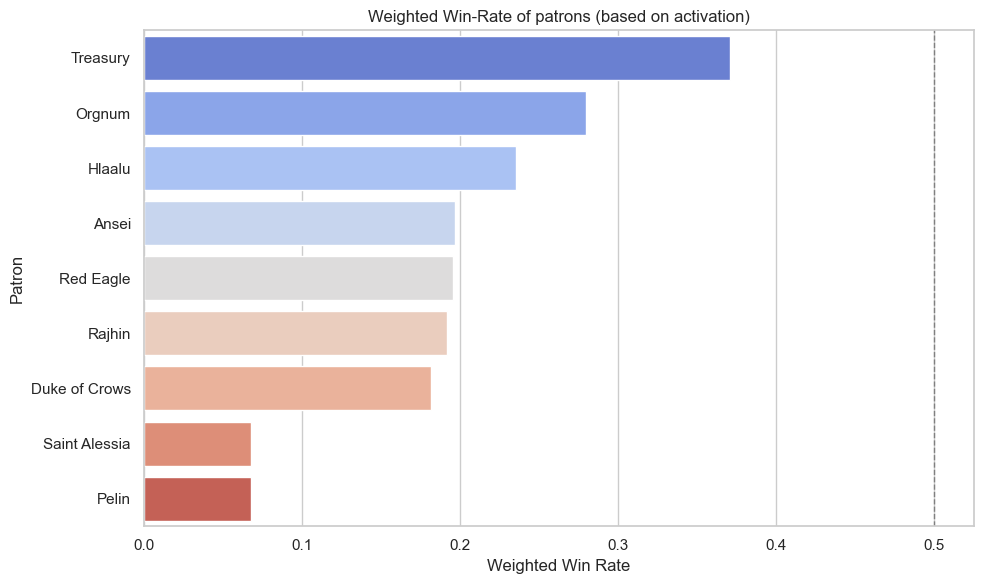

In [45]:
agg_patrons = agg_patrons.sort_values(by="weighted_win_rate", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=agg_patrons,
    x="weighted_win_rate",
    y="patron_name",
    palette="coolwarm"
)

plt.title("Weighted Win-Rate of patrons (based on activation)")
plt.xlabel("Weighted Win Rate")
plt.ylabel("Patron")
plt.axvline(0.5, linestyle="--", color="gray", linewidth=1, label="Poziom neutralny (0.5)")
plt.tight_layout()
plt.show()

In [37]:
agg_patrons[["patron_id", "patron_name", "weighted_win_rate"]].to_csv("patron_weighted_winrate.csv", index=False)

In [38]:
all_patron_names = [
    "ANSEI", "DUKE_OF_CROWS", "RAJHIN", "ORGNUM",
    "HLAALU", "PELIN", "RED_EAGLE", "SAINT_ALESSIA"
]

patron_turns = {name: [] for name in all_patron_names}

for _, row in ends_df.iterrows():
    patrons = row["patrons_state"]
    turns = row["turns"]

    for pname, value in patrons.items():
        if pname in patron_turns and value is not None:
            patron_turns[pname].append(turns)

patron_avg_turns = {
    pname: sum(turns) / len(turns) if turns else 0
    for pname, turns in patron_turns.items()
}


d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


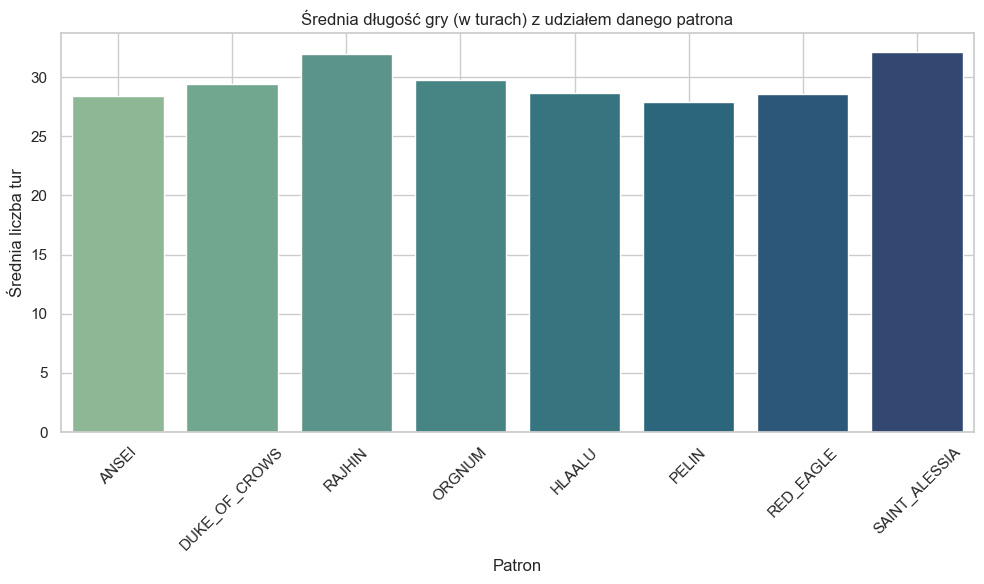

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(patron_avg_turns.keys()),
    y=list(patron_avg_turns.values()),
    palette="crest"
)
plt.title("Średnia długość gry (w turach) z udziałem danego patrona")
plt.ylabel("Średnia liczba tur")
plt.xlabel("Patron")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


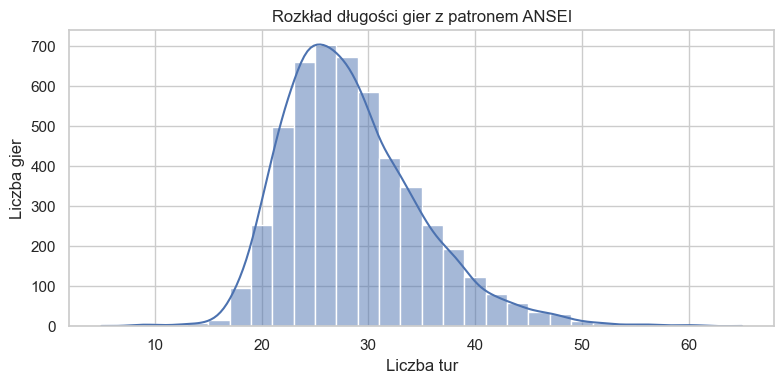

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


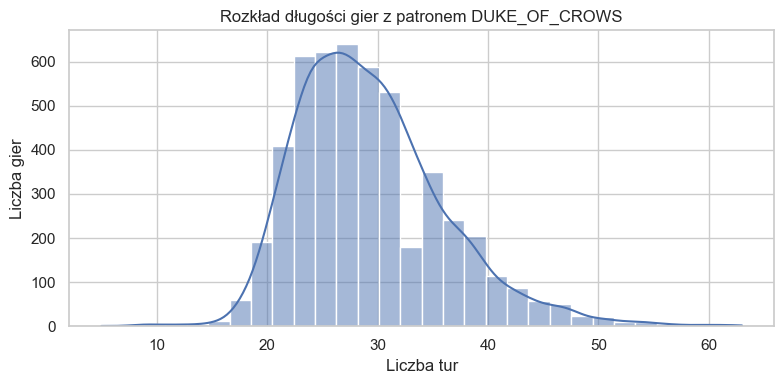

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


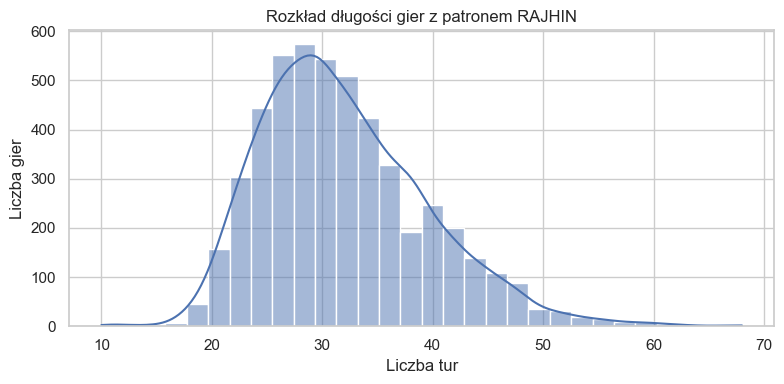

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


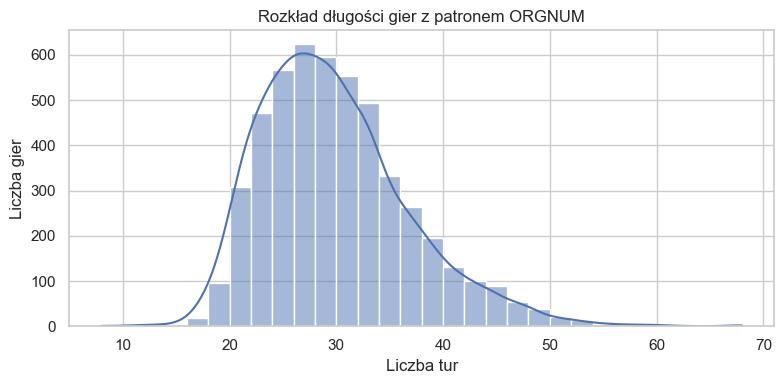

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


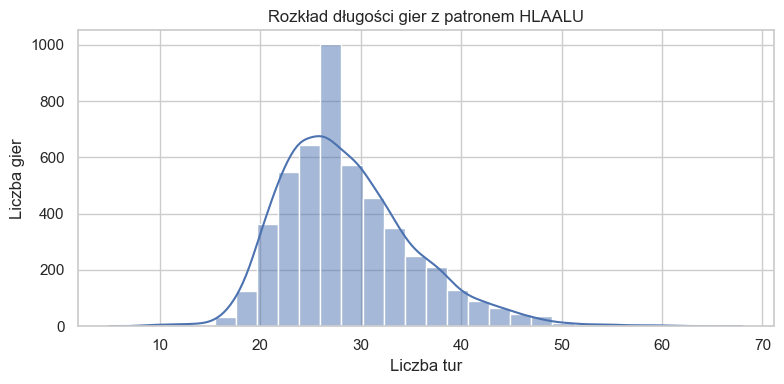

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


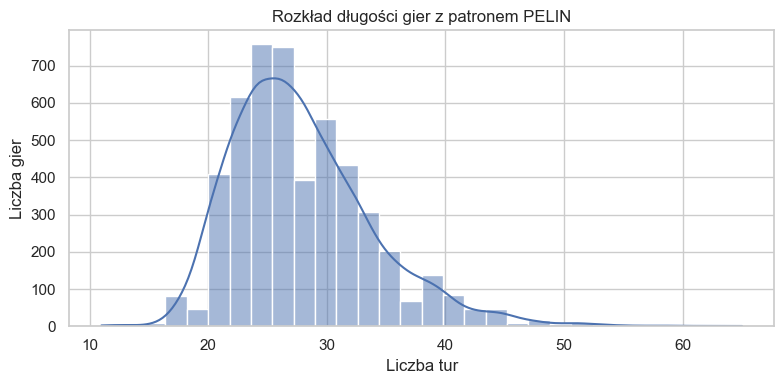

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


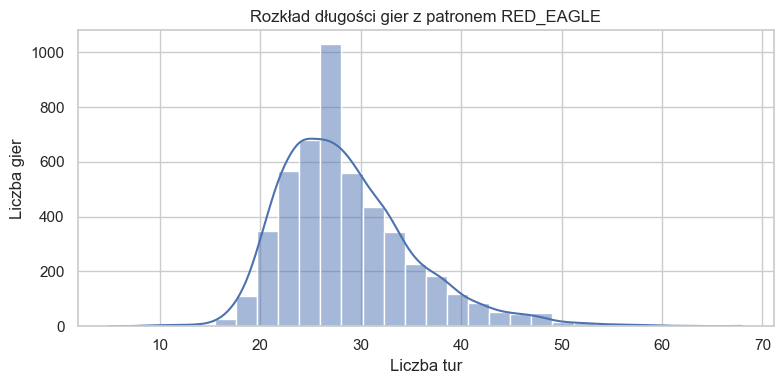

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


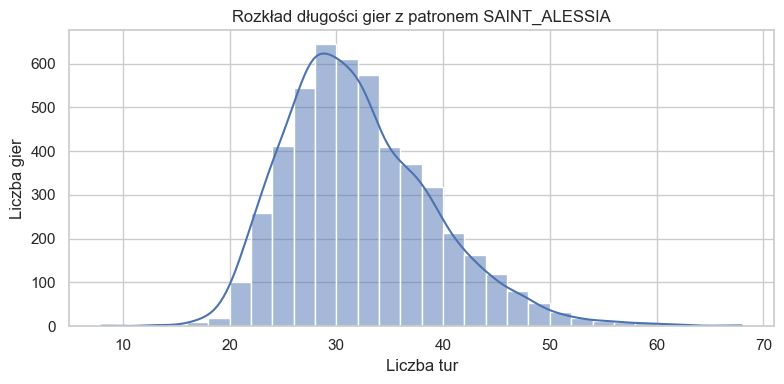

In [40]:
for pname, turns in patron_turns.items():
    if not turns:
        continue
    plt.figure(figsize=(8, 4))
    sns.histplot(turns, bins=30, kde=True)
    plt.title(f"Rozkład długości gier z patronem {pname}")
    plt.xlabel("Liczba tur")
    plt.ylabel("Liczba gier")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


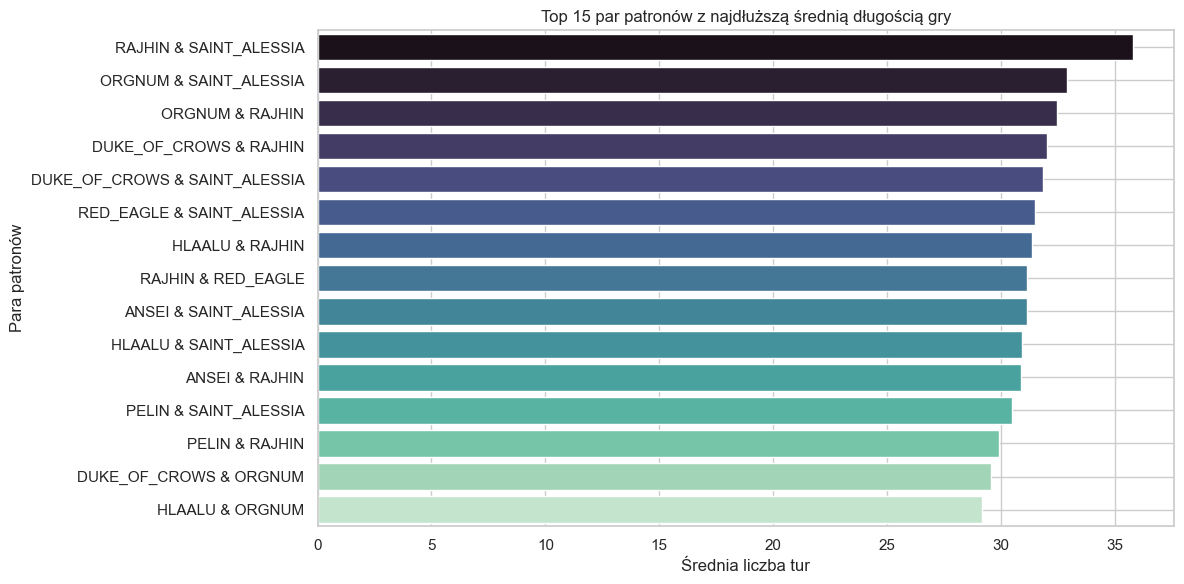

In [41]:
excluded_patrons = {"TREASURY", "PSIJIC"}
pair_turns = defaultdict(list)

for _, row in ends_df.iterrows():
    patrons = row["patrons_state"]
    turns = row["turns"]

    present = [p for p, v in patrons.items() if v is not None and p not in excluded_patrons]
    if len(present) < 2:
        continue

    for pair in combinations(present, 2):
        pair_key = frozenset(pair)
        pair_turns[pair_key].append(turns)

pair_avg_turns = {
    " & ".join(sorted(pair)): sum(turns) / len(turns)
    for pair, turns in pair_turns.items()
    if len(turns) >= 10
}

top_longest = sorted(pair_avg_turns.items(), key=lambda x: -x[1])[:15]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=[x[1] for x in top_longest],
    y=[x[0] for x in top_longest],
    palette="mako"
)
plt.title("Top 15 par patronów z najdłuższą średnią długością gry")
plt.xlabel("Średnia liczba tur")
plt.ylabel("Para patronów")
plt.grid(True)
plt.tight_layout()
plt.show()

d:\Coding\Venvs\DataScience\lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


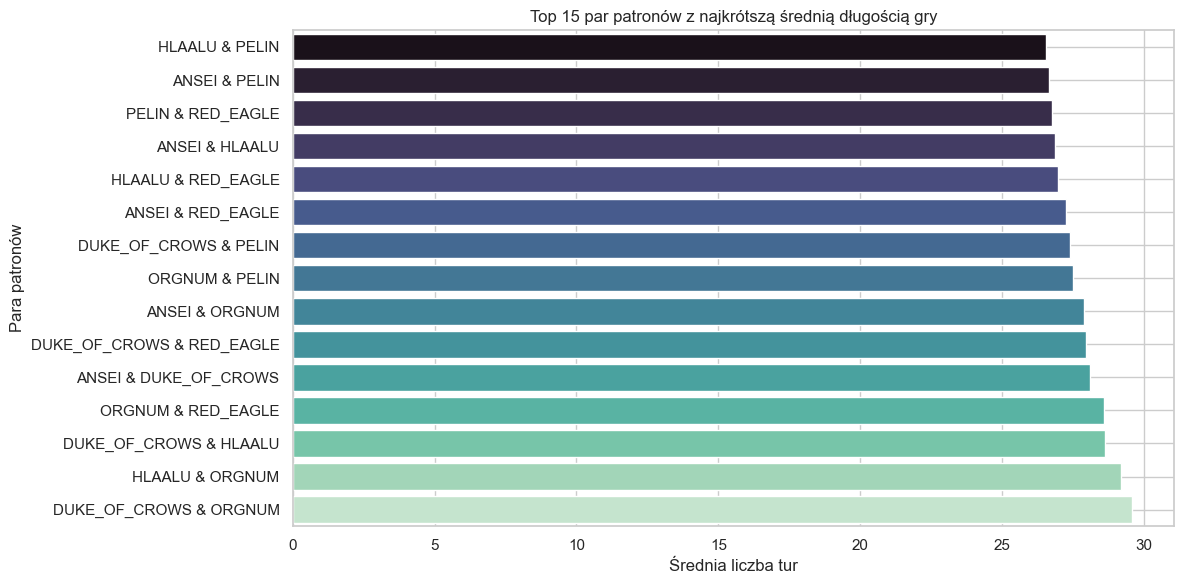

In [42]:
top_shortest = sorted(pair_avg_turns.items(), key=lambda x: x[1])[:15]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=[x[1] for x in top_shortest],
    y=[x[0] for x in top_shortest],
    palette="mako"
)
plt.title("Top 15 par patronów z najkrótszą średnią długością gry")
plt.xlabel("Średnia liczba tur")
plt.ylabel("Para patronów")
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
α = 0.5
agent_penalty = 0.5

def adjusted_play_ratio(row):
    cost = row["cost"]
    base_ratio = row["play_ratio"]
    if pd.isna(cost) or cost == 0:
        cost = α
    weight = base_ratio / (cost + α)
    if row["type"] == "Agent":
        weight *= agent_penalty

    return weight

df = pd.DataFrame(card_game_stats)

df["adjusted_ratio"] = df.apply(adjusted_play_ratio, axis=1)

agg = df.groupby("card_id").agg(
    total_plays=("plays", "sum"),
    total_adj_ratio=("adjusted_ratio", "sum"),
    weighted_win_score=("adjusted_ratio", lambda x: x.dot(df.loc[x.index, 'win']))
).reset_index()

agg["adjusted_win_rate"] = agg["weighted_win_score"] / agg["total_adj_ratio"]
agg["card_name"] = agg["card_id"].map(card_id_to_name)
agg = agg.sort_values(by="adjusted_win_rate", ascending=False)

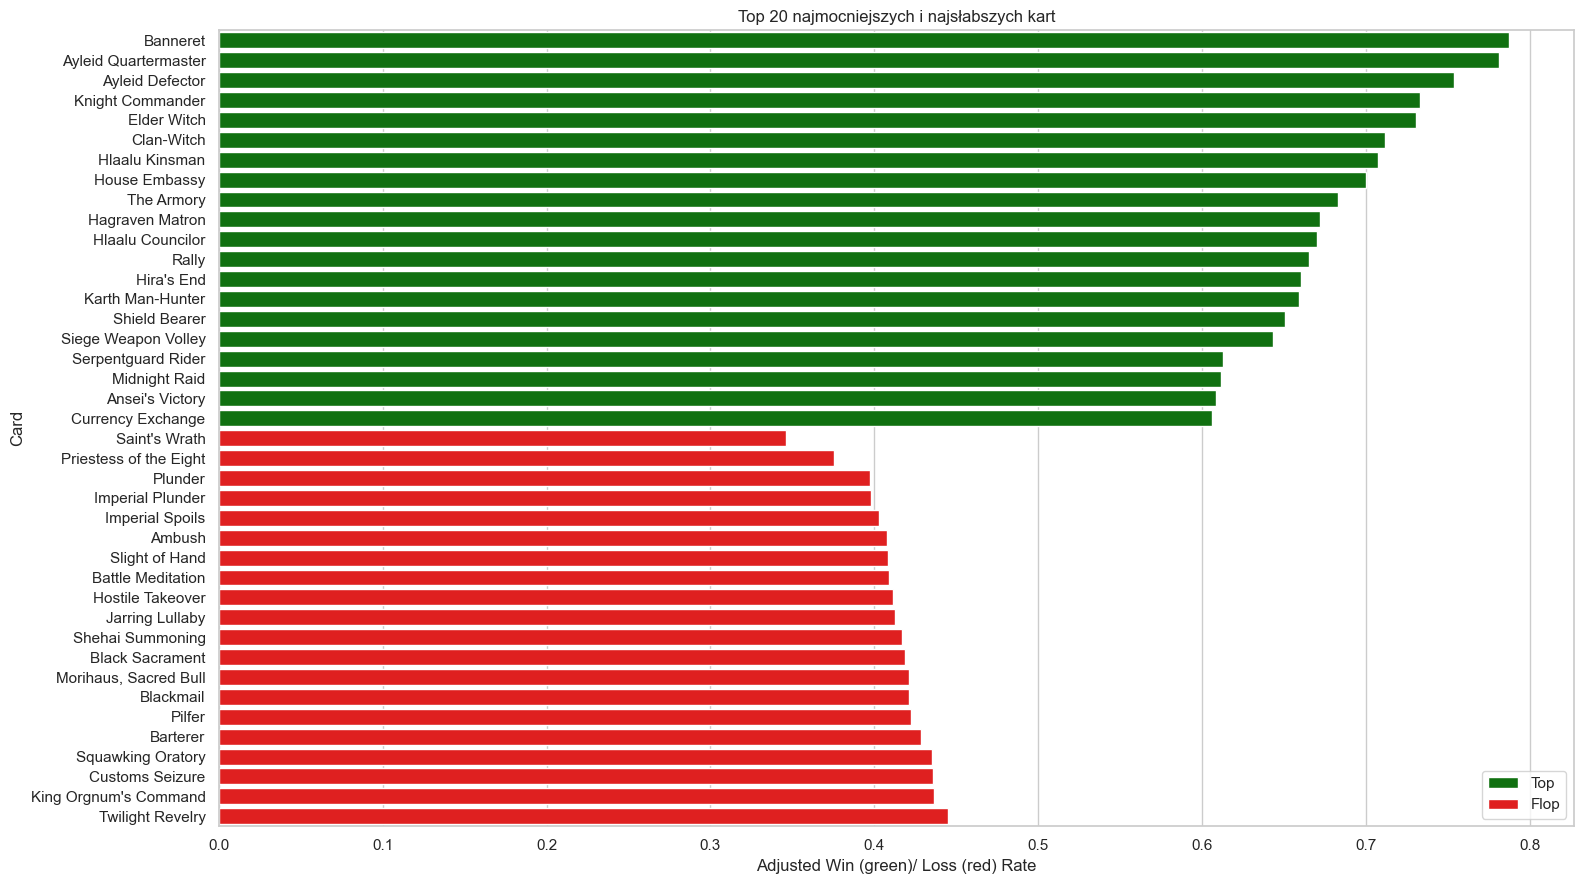

In [44]:
top_cards = agg.sort_values(by="adjusted_win_rate", ascending=False).head(20).copy()
flop_cards = agg.sort_values(by="adjusted_win_rate", ascending=True).head(20).copy()

top_cards["group"] = "Top"
flop_cards["group"] = "Flop"

combined = pd.concat([top_cards, flop_cards])

plt.figure(figsize=(16, 9))
sns.barplot(
    data=combined,
    x="adjusted_win_rate",
    y="card_name",
    hue="group",
    dodge=False,
    palette={"Top": "green", "Flop": "red"}
)
plt.xlabel("Adjusted Win (green)/ Loss (red) Rate")
plt.ylabel("Card")
plt.title("Top 20 najmocniejszych i najsłabszych kart")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()